### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.dummy import DummyClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

### Load the final processed data

Like Rohan's check, we'll do the same to make sure the work aligns. These will be identical to his to ensure consistency.

In [2]:
data_dir = Path("processed_data")

train_path = data_dir / "train_final.csv"
val_path = data_dir / "val_final.csv"
test_path = data_dir / "test_final.csv"

print("Train file exists:", train_path.exists())
print("Validation file exists:", val_path.exists())
print("Test file exists:", test_path.exists())


Train file exists: True
Validation file exists: True
Test file exists: True


In [3]:
train = pd.read_csv(train_path)
validation = pd.read_csv(val_path)

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)

train.head()

Train shape: (7746, 19)
Validation shape: (2584, 19)


,age,is_male,P_wave_duration_mean,P_wave_duration_std,PR_interval_mean,PR_interval_std,PR_segment_mean,PR_segment_std,QRS_duration_mean,QRS_duration_std,QT_interval_mean,QT_interval_std,ST_segment_mean,ST_segment_std,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_pNN50,target
0,-0.080067,-0.787935,-0.841006,-0.055135,1.089002,0.918455,1.332512,0.813291,-0.763211,-0.812053,0.201465,-0.630556,0.077558,-0.351457,0.946333,0.328705,-0.010365,1.386769,0
1,-1.191728,-0.787935,0.873540,-0.534451,0.366340,-0.757167,0.026520,-0.935958,-0.944048,-0.864915,0.020317,-0.806844,0.295670,-0.639444,0.672048,-0.043469,-0.208611,0.549509,0
2,-0.858230,1.269141,0.772142,-1.105336,0.294966,-0.833143,-0.003735,-0.984452,-0.775267,-0.795702,-0.018980,-0.771288,-0.039706,-0.865024,0.564292,-0.270677,-0.372043,-0.329613,0
3,0.753680,-0.787935,0.142246,-0.352941,-0.287922,-0.245758,-0.323090,-0.066711,0.534796,0.102527,0.171114,-0.353349,0.253455,0.068981,-0.308943,-0.508589,-0.483267,-0.706380,0
4,1.198344,1.269141,-0.687373,-0.249492,0.223592,-0.501063,0.461290,-0.524668,-0.413593,-0.444668,-1.675512,1.929814,-1.138082,2.036125,-0.123381,-0.196938,-0.380236,0.047154,0


In [4]:
print("Train columns:")
print(train.columns.tolist())

print("\nValidation columns:")
print(validation.columns.tolist())

Train columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']

Validation columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']


In [5]:
print("Train target counts:")
print(train["target"].value_counts().sort_index())

print("\nValidation target counts:")
print(validation["target"].value_counts().sort_index())

print("\nTrain positive rate:", round(train["target"].mean(), 3))
print("Validation positive rate:", round(validation["target"].mean(), 3))

Train target counts:
target
0    3885
1    3861
Name: count, dtype: int64

Validation target counts:
target
0    1291
1    1293
Name: count, dtype: int64

Train positive rate: 0.498
Validation positive rate: 0.5


In [6]:
drop_cols = ["target", "exam_id", "patient_id"]

feature_cols = [
    col for col in train.columns
    if col not in drop_cols
]

X_train = train[feature_cols]
y_train = train["target"]

X_val = validation[feature_cols]
y_val = validation["target"]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 18
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50']


Rohan's baseline gave us the following information:
{'model': 'Baseline',
 'C': nan,
 'accuracy': 0.4996130030959752,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': np.float64(0.5)}

In [7]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)
baseline_prob = baseline.predict_proba(X_val)[:, 1]

baseline_results = {
    "model": "Baseline",
    "accuracy": accuracy_score(y_val, baseline_pred),
    "precision": precision_score(y_val, baseline_pred, zero_division=0),
    "recall": recall_score(y_val, baseline_pred, zero_division=0),
    "f1": f1_score(y_val, baseline_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, baseline_prob)
}

baseline_results

{'model': 'Baseline',
 'accuracy': 0.4996130030959752,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5}

Using this, let's train a KNN model and see how it compares.

In [8]:
results = [baseline_results]

# KNN hyperparameter options
k_values = [3, 5, 10, 15, 20, 30, 35, 40, 45, 50]
weight_values = ["uniform", "distance"]
metric_values = ["euclidean", "manhattan"]

for k in k_values:
    for weight in weight_values:
        for metric in metric_values:

            model = KNeighborsClassifier(
                n_neighbors=k,
                weights=weight,
                metric=metric
            )

            model.fit(X_train, y_train)

            pred = model.predict(X_val)
            prob = model.predict_proba(X_val)[:, 1]

            results.append({
                "model": "KNN",
                "n_neighbors": k,
                "weights": weight,
                "metric": metric,
                "accuracy": accuracy_score(y_val, pred),
                "precision": precision_score(y_val, pred, zero_division=0),
                "recall": recall_score(y_val, pred, zero_division=0),
                "f1": f1_score(y_val, pred, zero_division=0),
                "roc_auc": roc_auc_score(y_val, prob)
            })

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc,n_neighbors,weights,metric
0,Baseline,0.499613,0.000000,0.000000,0.000000,0.500000,NaN,NaN,NaN
1,KNN,0.612616,0.614600,0.605568,0.610051,0.644410,3.0,uniform,euclidean
2,KNN,0.611842,0.618464,0.585460,0.601510,0.642326,3.0,uniform,manhattan
3,KNN,0.612616,0.614600,0.605568,0.610051,0.645283,3.0,distance,euclidean
4,KNN,0.611842,0.618464,0.585460,0.601510,0.645237,3.0,distance,manhattan
5,KNN,0.618034,0.621815,0.604022,0.612789,0.658215,5.0,uniform,euclidean
6,KNN,0.632353,0.636436,0.618716,0.627451,0.668460,5.0,uniform,manhattan
7,KNN,0.617647,0.621321,0.604022,0.612549,0.663302,5.0,distance,euclidean
8,KNN,0.631579,0.635640,0.617943,0.626667,0.670428,5.0,distance,manhattan
9,KNN,0.625774,0.656430,0.529002,0.585867,0.684374,10.0,uniform,euclidean


In [9]:
results_df.sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc,n_neighbors,weights,metric
40,KNN,0.655960,0.665033,0.629544,0.646802,0.722011,50.0,distance,manhattan
38,KNN,0.657895,0.677363,0.604022,0.638594,0.721047,50.0,uniform,manhattan
28,KNN,0.655573,0.663423,0.632637,0.647664,0.720413,35.0,distance,manhattan
36,KNN,0.651703,0.660147,0.626450,0.642857,0.719823,45.0,distance,manhattan
26,KNN,0.658669,0.667209,0.634184,0.650278,0.719813,35.0,uniform,manhattan
32,KNN,0.651316,0.660920,0.622583,0.641179,0.719075,40.0,distance,manhattan
34,KNN,0.650542,0.660626,0.620263,0.639809,0.718759,45.0,uniform,manhattan
30,KNN,0.653638,0.673951,0.596288,0.632745,0.718205,40.0,uniform,manhattan
24,KNN,0.653638,0.661264,0.631090,0.645825,0.717759,30.0,distance,manhattan
39,KNN,0.646285,0.652946,0.625677,0.639021,0.717134,50.0,distance,euclidean


In [10]:
# Pick the KNN model with the best validation ROC-AUC.
knn_results = results_df[results_df["model"] == "KNN"].copy()

best_row = knn_results.sort_values("roc_auc", ascending=False).iloc[0]
best_k = best_row["n_neighbors"]

print("Best k:", best_k)
print(best_row)

Best k: 50.0
model                KNN
accuracy         0.65596
precision       0.665033
recall          0.629544
f1              0.646802
roc_auc         0.722011
n_neighbors         50.0
weights         distance
metric         manhattan
Name: 40, dtype: object


In [11]:
# Pick the KNN model with the best validation accuracy.
knn_results = results_df[results_df["model"] == "KNN"].copy()

best_row = knn_results.sort_values("accuracy", ascending=False).iloc[0]
best_k = best_row["n_neighbors"]

print("Best k:", best_k)
print(best_row)

Best k: 35.0
model                KNN
accuracy        0.658669
precision       0.667209
recall          0.634184
f1              0.650278
roc_auc         0.719813
n_neighbors         35.0
weights          uniform
metric         manhattan
Name: 26, dtype: object


This shows that although ROC-AUC improves with the increased number of neighbors, accuracy begins to drop. We will stick with the model using 35 neighbors with uniform weight & manhattan metric.

In [12]:
best_model = KNeighborsClassifier(
    n_neighbors=int(best_k)
)

best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_val)
best_prob = best_model.predict_proba(X_val)[:, 1]

### Confusion Matrix

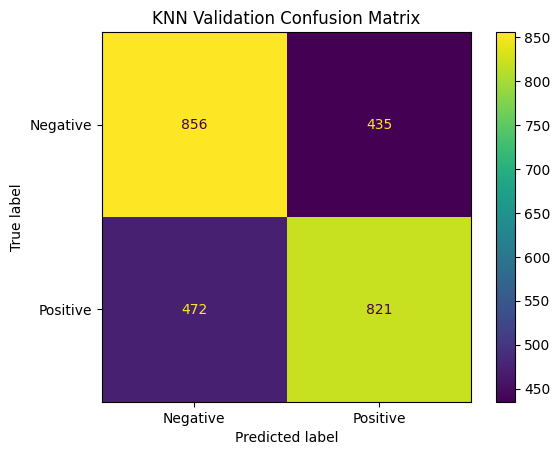

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    best_pred,
    display_labels=["Negative", "Positive"]
)

plt.title("KNN Validation Confusion Matrix")
plt.show()

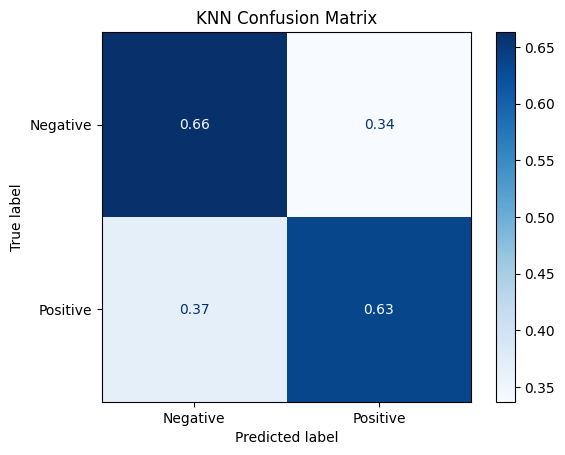

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    best_pred,
    cmap="Blues",
    normalize="true",
    display_labels=["Negative", "Positive"]
)

plt.title("KNN Confusion Matrix")
plt.show()

When trying to detect Chagas, we should be putting more emphasis on true positives and false negatives.

### ROC Curve

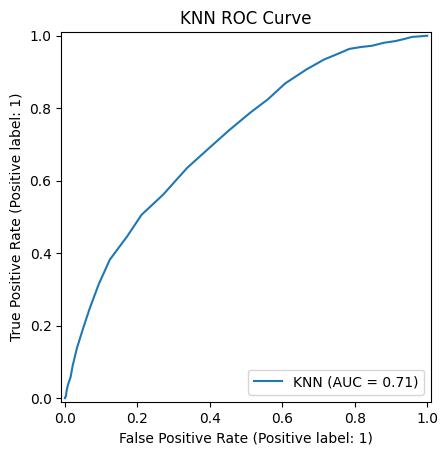

In [15]:
RocCurveDisplay.from_predictions(
    y_val, 
    best_prob, 
    name="KNN"
)
plt.title("KNN ROC Curve")
plt.show()

Unlike logistic regression, decision tree, or random forest, KNN doesn't put emphasis on a feature importance since it predicts based on distance between observations rather than feature weights. The next best thing was to check permutation performance to see which features contributed to its ROC-AUC score.

In [16]:
importance = permutation_importance(
    best_model,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

knn_feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance.importances_mean
})

knn_feature_importance = knn_feature_importance.sort_values(
    "importance",
    ascending=False
)

knn_feature_importance.head(10)

,feature,importance
0,age,0.031032
12,ST_segment_mean,0.025825
10,QT_interval_mean,0.014270
6,PR_segment_mean,0.010195
2,P_wave_duration_mean,0.008444
8,QRS_duration_mean,0.007540
14,HRV_MeanNN,0.006231
3,P_wave_duration_std,0.006141
13,ST_segment_std,0.005466
17,HRV_pNN50,0.005438


In [17]:
results_dir = Path("model_results")
results_dir.mkdir(exist_ok=True)

results_df.to_csv(results_dir / "knn_results.csv", index=False)

knn_feature_importance.to_csv(results_dir / "knn_permutation_importance.csv", index=False)
print("Saved KNN results and permutation importance to model_results/")

Saved KNN results and permutation importance to model_results/
